# Comparing 8 RAG Architectures using Python (Anthropic + FAISS)
#### Retrieval-Augmented Generation (RAG) is one of the most practical ways to give a large language model access to your own data. Here's how 8 popular RAG architectures compare on the same benchmark.

[Retrieval-Augmented Generation (RAG)](https://www.anthropic.com/news/contextual-retrieval) is a popular technique for grounding large language models (LLMs) in your own documents. Instead of relying purely on what the model learned during training, a RAG system retrieves relevant passages at query time and passes them to the LLM as context. However, there are many ways to design a RAG pipeline, and the choice of architecture has a big impact on answer quality, latency, and cost. This tutorial includes the following:

- What is RAG (and why there are so many variants)
- The 8 architectures we will compare
- Setting up the evaluation harness (SQuAD, embeddings, FAISS, metrics)
- Implementing each architecture step-by-step
- Running the benchmark and visualizing the results
- Discussion: when to use which architecture

The code used in this tutorial is available on my [GitHub](https://github.com/mGalarnyk/Python_Tutorials/blob/master/RAG/rag_comparison.ipynb). If you have questions about the content of this notebook, check out the [blog by Vidhyakshaya Kannan](https://thegenacademy.substack.com/p/which-rag-architecture-should-you).

## What is RAG

A plain LLM answers questions from the knowledge it picked up during training. That works well for general questions, but it has two obvious problems:

1. The model can't know about anything that happened after its training cutoff.
2. The model doesn't know anything specific to your documents, your company, or your niche.

RAG addresses both problems by splitting the pipeline into two steps. First, a **retriever** looks up the most relevant passages from a corpus you control. Then a **generator** (the LLM) is asked to answer the question using those passages as context. The retriever is typically a vector search index built on top of text embeddings. The diagram below shows the shape of the pipeline:

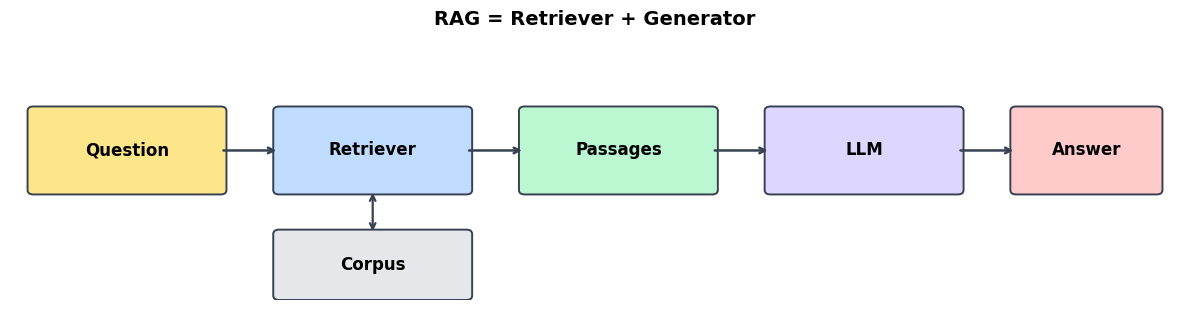

In [1]:
# A small matplotlib schematic of the RAG pipeline. This runs before any
# heavy dependencies so you can see the picture even on a fresh kernel.
import matplotlib.pyplot as _plt
import matplotlib.patches as _patches
import os as _os

_os.makedirs("images", exist_ok=True)
_fig, _ax = _plt.subplots(figsize=(12, 3.2))
_ax.set_xlim(0, 10); _ax.set_ylim(0, 3); _ax.axis("off")

_boxes = [
    ("Question",  0.2, 1.25, 1.6, 0.9, "#fde68a"),
    ("Retriever", 2.3, 1.25, 1.6, 0.9, "#bfdbfe"),
    ("Passages",  4.4, 1.25, 1.6, 0.9, "#bbf7d0"),
    ("LLM",       6.5, 1.25, 1.6, 0.9, "#ddd6fe"),
    ("Answer",    8.6, 1.25, 1.2, 0.9, "#fecaca"),
    ("Corpus",    2.3, 0.05, 1.6, 0.7, "#e5e7eb"),
]
for text, x, y, w, h, c in _boxes:
    _ax.add_patch(_patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                                          facecolor=c, edgecolor="#374151", linewidth=1.4))
    _ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=12, fontweight="bold")

for (x1, x2) in [(1.8, 2.3), (3.9, 4.4), (6.0, 6.5), (8.1, 8.6)]:
    _ax.annotate("", xy=(x2, 1.70), xytext=(x1, 1.70),
                 arrowprops=dict(arrowstyle="->", lw=1.8, color="#374151"))
_ax.annotate("", xy=(3.1, 0.75), xytext=(3.1, 1.25),
             arrowprops=dict(arrowstyle="<->", lw=1.6, color="#374151"))

_ax.set_title("RAG = Retriever + Generator", fontsize=14, fontweight="bold", pad=8)
_plt.tight_layout()
_fig.savefig("images/what_is_rag.png", dpi=150, bbox_inches="tight")
_plt.show()

This simple recipe, often called *naive RAG*, works surprisingly well. But it has plenty of weaknesses: noisy retrieval, coarse chunks, irrelevant context, multi-hop questions, and so on. That is why there are now many RAG variants, each fixing a different problem.

## The 8 Architectures We Will Compare

Every architecture in this tutorial uses the same embedding model ([`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)), the same FAISS vector store, and the same LLM (`claude-sonnet-4-6`). The only thing that changes is the retrieval / generation logic around them.

| # | Architecture | Key Idea |
|---|---|---|
| 1 | Naive RAG | Fixed-size chunking → embed → FAISS → LLM answer (retrieve-then-read baseline) |
| 2 | Advanced RAG | Sentence-aware chunking + multi-query expansion + cross-encoder reranking |
| 3 | HyDE | LLM writes a *hypothetical* answer → embed it → retrieve real passages from its neighborhood |
| 4 | FLARE | Generate with `[UNCERTAIN: …]` markers → retrieve for uncertain spans → regenerate |
| 5 | Self-RAG | LLM decides if retrieval is needed, filters passages (batched), checks grounding |
| 6 | CRAG | Classify each retrieved doc Relevant / Ambiguous / Irrelevant (batched); fall back to parametric |
| 7 | GraphRAG | Build a co-occurrence knowledge graph, detect communities, retrieve by community summary |
| 8 | Agentic RAG | Give Claude `retrieve` and `answer` tools and let it plan multi-step retrievals |

We benchmark the first six plus Agentic RAG on **SQuAD span questions** (short factoid answers), then evaluate GraphRAG separately on synthesis questions where it's actually designed to shine, and finally test the retrieve-then-read architectures on a small HotpotQA multi-hop subset.

## Installing the Dependencies

The code below installs everything you need to run this notebook. If you are on Colab or a fresh environment, run it once. If you already have these installed locally, feel free to skip it.

`tenacity` is used for retry-with-backoff on API errors; `ipywidgets` silences a tqdm warning when HuggingFace datasets loads.

In [2]:
%pip install -q anthropic sentence-transformers faiss-cpu datasets networkx python-louvain pandas matplotlib seaborn scikit-learn tqdm tenacity ipywidgets

Note: you may need to restart the kernel to use updated packages.


## Import Libraries

A quick note on what each library is for:

- [`anthropic`](https://github.com/anthropics/anthropic-sdk-python) — client for Claude.
- [`sentence-transformers`](https://www.sbert.net/) — the embedding model and the cross-encoder used for reranking in Advanced RAG.
- [`faiss-cpu`](https://github.com/facebookresearch/faiss) — the vector store.
- [`datasets`](https://huggingface.co/docs/datasets) — SQuAD v1.1 + HotpotQA for the multi-hop section.
- [`networkx`](https://networkx.org/) + [`python-louvain`](https://python-louvain.readthedocs.io/en/latest/) — the graph and community detection used in GraphRAG.
- [`tenacity`](https://tenacity.readthedocs.io/en/latest/) — retry with exponential backoff for the API calls.

In [3]:
import os
import re
import time
import json
import string
import getpass
import functools
import warnings
from typing import List, Dict, Tuple, Any, Optional
from dataclasses import dataclass, field
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
import networkx as nx
from sentence_transformers import SentenceTransformer, CrossEncoder
from datasets import load_dataset
import anthropic
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("Imports OK")

Imports OK


## Setting Up Your Anthropic API Key

All 8 architectures call Claude, so you need an Anthropic API key. You can get one from the [Anthropic Console](https://console.anthropic.com/settings/keys).

**Never paste your key directly into a notebook cell.** If you do, it can leak via `.ipynb_checkpoints/`, via git history, or when you share the notebook. The cell below loads the key in this order:

1. `ANTHROPIC_API_KEY` already set in the shell you launched Jupyter from.
2. A `.env` file next to the notebook or at the project root, with a line like `ANTHROPIC_API_KEY=sk-ant-...`. The `.gitignore` in this repo already excludes `*.env`, so the file stays local.
3. An interactive `getpass` prompt as a last resort.

Whichever path is used, the key is held in memory only — it is never printed, written into notebook outputs, or persisted by this notebook.

In [4]:
def _load_api_key() -> str:
    key = os.environ.get("ANTHROPIC_API_KEY")
    if key:
        return key
    for env_path in (".env", "../.env"):
        if os.path.exists(env_path):
            with open(env_path) as fh:
                for line in fh:
                    line = line.strip()
                    if line.startswith("ANTHROPIC_API_KEY="):
                        return line.split("=", 1)[1].strip().strip('"').strip("'")
    return getpass.getpass("Enter your Anthropic API key (hidden): ")


api_key = _load_api_key()
assert api_key.startswith("sk-"), "That doesn't look like a valid Anthropic key."
os.environ["ANTHROPIC_API_KEY"] = api_key  # in-memory only

MODEL = "claude-sonnet-4-6"
TOP_K = 5
N_EVAL = 50          # span questions (SQuAD)
N_SYNTHESIS = 5      # synthesis questions for GraphRAG
N_MULTIHOP = 5       # HotpotQA multi-hop questions

client   = anthropic.Anthropic(api_key=api_key)
embedder = SentenceTransformer("all-MiniLM-L6-v2")
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("API key loaded. Models loaded.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


API key loaded. Models loaded.


## Load the Dataset

For the main benchmark we use [SQuAD v1.1](https://huggingface.co/datasets/rajpurkar/squad) — the Stanford Question Answering Dataset. It pairs Wikipedia paragraphs with questions whose answer is a short span from the paragraph. That makes it a convenient benchmark because:

- The answer is a short, exact string we can score with token F1 *and* an LLM judge.
- Each paragraph can act as one document in our corpus.
- The questions are phrased naturally, so the retriever actually has to work.

The code below downloads the validation split, keeps a ~200-passage corpus, and reserves 10 questions for evaluation.

In [5]:
squad = load_dataset("rajpurkar/squad", split="validation")
shuffled = squad.shuffle(seed=42).select(range(200))

eval_questions = []
corpus_passages = []
seen_contexts = set()

for item in shuffled:
    ctx = item["context"]
    if ctx not in seen_contexts:
        corpus_passages.append(ctx)
        seen_contexts.add(ctx)
    if len(eval_questions) < N_EVAL:
        eval_questions.append({
            "question": item["question"],
            "answer":   item["answers"]["text"][0],
            "context":  ctx,
        })

print(f"Corpus: {len(corpus_passages)} passages | Eval: {len(eval_questions)} questions\n")
for i, qa in enumerate(eval_questions):
    print(f"  [{i+1}] Q: {qa['question'][:70]}")
    print(f"       A: {qa['answer']}")

Corpus: 192 passages | Eval: 50 questions

  [1] Q: In what year did Massachusetts first require children to be educated i
       A: 1852
  [2] Q: When were stromules discovered?
       A: 1962
  [3] Q: Which artist who had a major influence on the Gothic Revival is repres
       A: Horace Walpole
  [4] Q: In 1890, who did the university decide to team up with?
       A: several regional colleges and universities
  [5] Q: Who got a touchdown making the score 10-7?
       A: Jonathan Stewart
  [6] Q: How many Examination Boards exist in India?
       A: 30
  [7] Q: Who started rumors in 2008 that ABC would sell its ten owned-and-opera
       A: Caris & Co.
  [8] Q: Which network broadcasted the 50th Super Bowl game? 
       A: CBS
  [9] Q: Why was this short termed organization created?
       A: coordinate the response to the embargo
  [10] Q: What does LGM stands for?
       A: Last Glacial Maximum
  [11] Q: What is the paper written by Richard Karp in 1972 that ushered in a ne
      

## Building the Shared Infrastructure

Before we implement any of the 8 architectures, we set up five pieces of shared infrastructure they all use:

1. **Chunking functions** — how to split a passage into smaller, embeddable pieces.
2. **A `VectorStore` class** — wraps FAISS so each architecture can build an index and search it with one line.
3. **A cached `embed()` helper** — an `lru_cache` around `embedder.encode` so we don't re-embed the same gold answer dozens of times during evaluation.
4. **A retry-wrapped `llm()` helper** — calls Claude with exponential backoff and tracks token usage per architecture.
5. **Evaluation metrics** — token F1, semantic similarity, context recall, and an LLM-as-judge correctness flag.

### Chunking

In [6]:
def chunk_text(text: str, size: int = 400, overlap: int = 50) -> List[str]:
    """Fixed-size character chunking with overlap."""
    chunks = []
    start = 0
    while start < len(text):
        chunks.append(text[start:start + size])
        start += size - overlap
    return [c for c in chunks if len(c.strip()) > 20]


def sentence_chunk(text: str, max_chars: int = 500) -> List[str]:
    """Sentence-aware chunking: split on sentence boundaries, pack to ~max_chars."""
    sentences = re.split(r'(?<=[.!?])\s+', text)
    chunks, current = [], ""
    for sent in sentences:
        if len(current) + len(sent) + 1 <= max_chars:
            current = (current + " " + sent).strip()
        else:
            if current:
                chunks.append(current)
            current = sent
    if current:
        chunks.append(current)
    return [c for c in chunks if len(c.strip()) > 20]

### Cached Embeddings

During evaluation the same gold answers and questions get embedded repeatedly (for semantic similarity, for context recall, etc.). Wrapping the encoder in an `lru_cache` avoids re-computing those embeddings.

In [7]:
@functools.lru_cache(maxsize=4096)
def _embed_cached(text: str) -> tuple:
    """Cached single-string embedding. Returns a tuple so it's hashable if ever reused."""
    return tuple(embedder.encode([text], normalize_embeddings=True)[0].tolist())


def embed_one(text: str) -> np.ndarray:
    return np.array(_embed_cached(text), dtype="float32")


def embed_many(texts: List[str]) -> np.ndarray:
    return np.stack([embed_one(t) for t in texts]).astype("float32")

### Vector Store

Uses FAISS `IndexFlatIP` because we L2-normalize the embeddings, making inner-product equivalent to cosine similarity.

In [8]:
@dataclass
class VectorStore:
    chunks: List[str] = field(default_factory=list)
    index: Any = field(default=None, repr=False)

    def build(self, passages: List[str], chunk_fn=chunk_text):
        self.chunks = []
        for p in passages:
            self.chunks.extend(chunk_fn(p))
        print(f"  Building index over {len(self.chunks)} chunks…", end=" ")
        embs = embedder.encode(self.chunks, batch_size=64, show_progress_bar=False,
                               normalize_embeddings=True).astype("float32")
        self.index = faiss.IndexFlatIP(embs.shape[1])
        self.index.add(embs)
        print("done.")

    def search(self, query: str, k: int = 5) -> List[Tuple[str, float]]:
        q_emb = embedder.encode([query], normalize_embeddings=True).astype("float32")
        scores, idxs = self.index.search(q_emb, min(k, len(self.chunks)))
        return [(self.chunks[i], float(s)) for i, s in zip(idxs[0], scores[0]) if i >= 0]

### LLM Wrapper with Retry + Token Tracking

Three things to notice here:

1. **Retry with exponential backoff** — one 429 or 529 no longer ruins an architecture's score for a question.
2. **A global token counter** (`TOKEN_USAGE`) we tag with the architecture name, so we can report cost at the end.
3. **Span-style system prompt** — we tell Claude to answer with the shortest literal span from the context rather than writing prose. This is what actually fixes the misleadingly-low F1 scores you see on SQuAD-style benchmarks.

In [9]:
TOKEN_USAGE: Dict[str, Dict[str, int]] = defaultdict(lambda: {"input": 0, "output": 0, "calls": 0})
CURRENT_ARCH: List[str] = ["misc"]  # a one-element list we can mutate from context managers


class _ArchScope:
    """with arch('Naive RAG'):  all llm() calls inside get tagged to that architecture."""
    def __init__(self, name): self.name = name
    def __enter__(self): CURRENT_ARCH.append(self.name); return self
    def __exit__(self, *a): CURRENT_ARCH.pop()


def arch(name: str) -> _ArchScope:
    return _ArchScope(name)


SPAN_SYSTEM = (
    "You are a precise question-answering assistant. "
    "When given a context, answer with the shortest literal span from the context that answers the question. "
    "No prose, no punctuation beyond what is in the span, no explanations. "
    "If the answer is not in the context, reply exactly: NOT_FOUND."
)


@retry(
    stop=stop_after_attempt(4),
    wait=wait_exponential(multiplier=1, min=1, max=20),
    retry=retry_if_exception_type((anthropic.RateLimitError, anthropic.APIConnectionError, anthropic.InternalServerError)),
    reraise=True,
)
def _call_llm(prompt: str, system: str, max_tokens: int):
    return client.messages.create(
        model=MODEL, max_tokens=max_tokens, system=system,
        messages=[{"role": "user", "content": prompt}],
    )


def llm(prompt: str, system: str = SPAN_SYSTEM, max_tokens: int = 128) -> str:
    """Call Claude with retry + token tracking. Returns plain text."""
    msg = _call_llm(prompt, system, max_tokens)
    usage = getattr(msg, "usage", None)
    if usage is not None:
        bucket = TOKEN_USAGE[CURRENT_ARCH[-1]]
        bucket["input"]  += getattr(usage, "input_tokens", 0)
        bucket["output"] += getattr(usage, "output_tokens", 0)
        bucket["calls"]  += 1
    return msg.content[0].text.strip()

### Evaluation Metrics

We score each architecture on five things:

- **Answer F1** — token-level F1 between predicted and gold answer (same metric SQuAD uses). Good continuity with prior work but punishes prose answers.
- **Answer Correctness (LLM judge)** — one extra Claude call per answer that returns CORRECT / INCORRECT. Forgiving of paraphrase and formatting. This is the metric we'll foreground.
- **Semantic Similarity** — cosine similarity between predicted and gold answer embeddings.
- **Context Recall** — max cosine similarity between gold answer and any retrieved chunk. Tells us whether the retriever even found the right passage.
- **Latency** — wall-clock seconds per question.

In [10]:
def normalize_answer(s: str) -> str:
    s = s.lower()
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    s = s.translate(str.maketrans('', '', string.punctuation))
    return ' '.join(s.split())


def f1_score(pred: str, gold: str) -> float:
    pred_toks = normalize_answer(pred).split()
    gold_toks = normalize_answer(gold).split()
    common = Counter(pred_toks) & Counter(gold_toks)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_toks)
    recall    = num_same / len(gold_toks)
    return 2 * precision * recall / (precision + recall)


def semantic_similarity(pred: str, gold: str) -> float:
    embs = np.stack([embed_one(pred), embed_one(gold)])
    return float(np.dot(embs[0], embs[1]))


def context_recall(gold_answer: str, contexts: List[str]) -> float:
    if not contexts:
        return 0.0
    gold_emb = embed_one(gold_answer)
    ctx_embs = embed_many(contexts)
    return float(np.max(ctx_embs @ gold_emb))


JUDGE_SYSTEM = (
    "You grade question-answering systems. Given a question, a gold answer, and a predicted answer, "
    "decide whether the prediction is CORRECT — a faithful paraphrase or superset of the gold answer — "
    "or INCORRECT. Reply with exactly one token: CORRECT or INCORRECT."
)


def llm_judge(question: str, pred: str, gold: str) -> int:
    """Return 1 if the predicted answer is judged correct, 0 otherwise."""
    with arch("judge"):
        verdict = llm(
            f"Question: {question}\nGold answer: {gold}\nPredicted answer: {pred}\nVerdict:",
            system=JUDGE_SYSTEM, max_tokens=4,
        )
    return 1 if "CORRECT" in verdict.upper() and "INCORRECT" not in verdict.upper() else 0


@dataclass
class EvalResult:
    architecture: str
    question:     str
    answer:       str
    gold_answer:  str
    contexts:     List[str]
    latency:      float
    f1:           float = 0.0
    correct:      int   = 0
    semantic_sim: float = 0.0
    ctx_recall:   float = 0.0

    def compute_metrics(self) -> "EvalResult":
        self.f1           = f1_score(self.answer, self.gold_answer)
        self.correct      = llm_judge(self.question, self.answer, self.gold_answer)
        self.semantic_sim = semantic_similarity(self.answer, self.gold_answer)
        self.ctx_recall   = context_recall(self.gold_answer, self.contexts)
        return self

### Build the Vector Stores

Naive RAG uses fixed-size chunks; Advanced RAG uses sentence-aware chunks.

In [11]:
print("Building naive_store (fixed-size chunks)…")
naive_store = VectorStore()
naive_store.build(corpus_passages, chunk_fn=chunk_text)

print("Building advanced_store (sentence-aware chunks)…")
advanced_store = VectorStore()
advanced_store.build(corpus_passages, chunk_fn=sentence_chunk)

print("Vector stores ready.")

Building naive_store (fixed-size chunks)…
  Building index over 511 chunks… done.
Building advanced_store (sentence-aware chunks)…
  Building index over 436 chunks… done.
Vector stores ready.


### A shared "answer from context" helper

All of the retrieve-then-read architectures end with the same pattern: hand the LLM the retrieved chunks and ask for the answer. The helper below centralizes that so we can tweak the prompt in one place.

In [12]:
ANSWER_USER_TEMPLATE = (
    "Context:\n{ctx}\n\n"
    "Question: {q}\n\n"
    "Answer with the shortest literal span from the context. No prose."
)


def answer_from_context(question: str, contexts: List[str]) -> str:
    if not contexts:
        return llm(f"Question: {question}\nAnswer:", max_tokens=32)
    ctx_str = "\n\n".join(f"[{i+1}] {c}" for i, c in enumerate(contexts))
    return llm(ANSWER_USER_TEMPLATE.format(ctx=ctx_str, q=question), max_tokens=64)

## 1. Naive RAG

**Step 1:** Chunk the corpus into fixed-size windows (400 chars, 50-char overlap).

**Step 2:** Embed chunks with `all-MiniLM-L6-v2` and store in FAISS.

**Step 3:** At query time, retrieve the top-K most similar chunks.

**Step 4:** Concatenate those chunks as context and ask the LLM to answer.

This is the retrieve-then-read baseline. Every other architecture in this tutorial can be understood as a modification of one of these four steps.

In [13]:
def naive_rag(question: str, store: "VectorStore" = None,
              arch_name: str = "Naive RAG") -> Tuple[str, List[str], float]:
    store = store or naive_store
    t0 = time.time()
    with arch(arch_name):
        contexts = [r[0] for r in store.search(question, k=TOP_K)]
        answer   = answer_from_context(question, contexts)
    return answer, contexts, time.time() - t0


_ans, _ctx, _lat = naive_rag(eval_questions[0]["question"])
print(f"Naive RAG smoke test ({_lat:.2f}s): {_ans[:120]}")


Naive RAG smoke test (1.74s): 1852


## 2. Advanced RAG

Three upgrades on the naive baseline:

1. **Sentence-aware chunking** — chunks respect sentence boundaries (~500 chars).
2. **Multi-query expansion** — the LLM rephrases the question two additional ways.
3. **Cross-encoder reranking** — all candidates are re-scored with `ms-marco-MiniLM-L-6-v2`, a pointwise relevance model.

In [14]:
REPHRASE_SYSTEM = "You rephrase questions. Return exactly 3 rephrasings, one per line, no numbering, no explanation."


def advanced_rag(question: str, store: "VectorStore" = None,
                 arch_name: str = "Advanced RAG") -> Tuple[str, List[str], float]:
    store = store or advanced_store
    t0 = time.time()
    with arch(arch_name):
        raw = llm(f"Rephrase: {question}", system=REPHRASE_SYSTEM, max_tokens=120)
        queries = [question] + [q.strip() for q in raw.strip().split("\n") if q.strip()][:2]

        seen, candidates = set(), []
        for q in queries:
            for chunk, _ in store.search(q, k=3):
                if chunk not in seen:
                    candidates.append(chunk); seen.add(chunk)

        if candidates:
            scores = reranker.predict([(question, c) for c in candidates])
            ranked = sorted(zip(scores, candidates), reverse=True)
            contexts = [c for _, c in ranked[:TOP_K]]
        else:
            contexts = []

        answer = answer_from_context(question, contexts)
    return answer, contexts, time.time() - t0


_ans, _ctx, _lat = advanced_rag(eval_questions[0]["question"])
print(f"Advanced RAG smoke test ({_lat:.2f}s): {_ans[:120]}")


Advanced RAG smoke test (3.34s): 1852


## 3. HyDE (Hypothetical Document Embeddings)

**Key insight:** the embedding space aligns better if we search using a *hypothetical answer* rather than the raw question.

> Gao et al., 2022 — *[Precise Zero-Shot Dense Retrieval without Relevance Labels](https://arxiv.org/abs/2212.10496)*

In [15]:
HYPO_SYSTEM = "You write a brief, confident factual answer to the user's question. Keep it to one short sentence."


def hyde_rag(question: str) -> Tuple[str, List[str], float]:
    t0 = time.time()
    with arch("HyDE"):
        hypo_answer = llm(question, system=HYPO_SYSTEM, max_tokens=60)

        hypo_emb = embedder.encode([hypo_answer], normalize_embeddings=True).astype("float32")
        _, idxs = naive_store.index.search(hypo_emb, TOP_K)
        contexts = [naive_store.chunks[i] for i in idxs[0] if i >= 0]

        answer = answer_from_context(question, contexts)
    return answer, contexts, time.time() - t0


_ans, _ctx, _lat = hyde_rag(eval_questions[0]["question"])
print(f"HyDE smoke test ({_lat:.2f}s): {_ans[:120]}")

HyDE smoke test (4.51s): 1852


## 4. FLARE (Forward-Looking Active REtrieval)

**Key insight:** retrieve *on demand* whenever the model is uncertain, rather than once upfront.

> Jiang et al., 2023 — *[Active Retrieval Augmented Generation](https://arxiv.org/abs/2305.06983)*

In [16]:
FLARE_DRAFT_SYSTEM = (
    "Answer the user's question. Wrap any part you are uncertain about in [UNCERTAIN: ...]. "
    "Keep the answer to one sentence."
)


def flare_rag(question: str) -> Tuple[str, List[str], float]:
    t0 = time.time()
    with arch("FLARE"):
        draft = llm(question, system=FLARE_DRAFT_SYSTEM, max_tokens=160)
        uncertain_spans = re.findall(r'\[UNCERTAIN:\s*(.*?)\]', draft, re.DOTALL)

        all_contexts, seen = [], set()
        for chunk, _ in naive_store.search(question, k=3):
            if chunk not in seen:
                all_contexts.append(chunk); seen.add(chunk)
        for span in uncertain_spans[:3]:
            for chunk, _ in naive_store.search(f"{question} {span}", k=2):
                if chunk not in seen:
                    all_contexts.append(chunk); seen.add(chunk)

        contexts = all_contexts[:TOP_K]
        answer = answer_from_context(question, contexts)
    return answer, contexts, time.time() - t0


_ans, _ctx, _lat = flare_rag(eval_questions[0]["question"])
print(f"FLARE smoke test ({_lat:.2f}s): {_ans[:120]}")

FLARE smoke test (3.76s): 1852


## 5. Self-RAG (with batched relevance filtering)

**Key insight:** the LLM should be an *active participant* in the retrieval process — deciding when to retrieve, which passages are actually relevant, and whether its final answer is grounded.

The original Self-RAG does *one LLM call per retrieved passage* to score relevance. On 7 candidates that's 7 sequential API calls per question. We fix this by **batching** all candidates into a single call that returns a CSV of 1/0 labels.

> Asai et al., 2023 — *[Self-RAG: Learning to Retrieve, Generate, and Critique through Self-Reflection](https://arxiv.org/abs/2310.11511)*

In [17]:
RELEVANCE_BATCH_SYSTEM = (
    "You score passage relevance. Reply with ONLY a comma-separated list of 1/0, one per passage, in order. "
    "1 = useful for answering the question, 0 = not useful. No explanation."
)


def _batched_relevance(question: str, candidates: List[str]) -> List[bool]:
    numbered = "\n".join(f"[{i+1}] {c[:350]}" for i, c in enumerate(candidates))
    reply = llm(
        f"Question: {question}\n\nPassages:\n{numbered}\n\nCSV of 1/0 (length {len(candidates)}):",
        system=RELEVANCE_BATCH_SYSTEM, max_tokens=64,
    )
    labels = re.findall(r"[01]", reply)
    labels = (labels + ["0"] * len(candidates))[: len(candidates)]
    return [lab == "1" for lab in labels]


def self_rag(question: str) -> Tuple[str, List[str], float]:
    t0 = time.time()
    with arch("Self-RAG"):
        retrieval_decision = llm(
            f"Can you answer confidently without external sources? Reply YES or NO.\nQuestion: {question}",
            system="Reply with exactly YES or NO.", max_tokens=4,
        )
        needs_retrieval = "NO" in retrieval_decision.upper()

        contexts = []
        if needs_retrieval:
            candidates = [r[0] for r in naive_store.search(question, k=TOP_K + 2)]
            keep = _batched_relevance(question, candidates)
            contexts = [c for c, k in zip(candidates, keep) if k][:TOP_K] or candidates[:TOP_K]

        answer = answer_from_context(question, contexts)
    return answer, contexts, time.time() - t0


_ans, _ctx, _lat = self_rag(eval_questions[0]["question"])
print(f"Self-RAG smoke test ({_lat:.2f}s): {_ans[:120]}")

Self-RAG smoke test (3.77s): 1852


## 6. Corrective RAG (CRAG, with batched classification)

**Key insight:** not all retrieved documents are equally useful. CRAG explicitly classifies each retrieved document as Relevant, Ambiguous, or Irrelevant — and falls back to parametric knowledge if nothing is relevant. We batch the classification into a single call.

> Yan et al., 2024 — *[Corrective Retrieval Augmented Generation](https://arxiv.org/abs/2401.15884)*

In [18]:
CRAG_BATCH_SYSTEM = (
    "You classify passage relevance. For each numbered passage, output a single letter: "
    "R (relevant), A (ambiguous), or I (irrelevant). Reply with a comma-separated list, no explanation."
)


def _batched_classify(question: str, candidates: List[str]) -> List[str]:
    numbered = "\n".join(f"[{i+1}] {c[:400]}" for i, c in enumerate(candidates))
    reply = llm(
        f"Question: {question}\n\nPassages:\n{numbered}\n\nCSV of R/A/I (length {len(candidates)}):",
        system=CRAG_BATCH_SYSTEM, max_tokens=64,
    )
    letters = re.findall(r"[RAIrai]", reply)
    letters = [c.upper() for c in letters]
    letters = (letters + ["I"] * len(candidates))[: len(candidates)]
    return letters


def crag_rag(question: str) -> Tuple[str, List[str], float]:
    t0 = time.time()
    with arch("CRAG"):
        candidates = [r[0] for r in naive_store.search(question, k=TOP_K)]
        labels = _batched_classify(question, candidates)

        relevant, ambiguous = [], []
        for chunk, lab in zip(candidates, labels):
            if lab == "R":
                relevant.append(chunk)
            elif lab == "A":
                ambiguous.append(chunk)

        final_contexts = list(relevant)
        for chunk in ambiguous:
            extracted = llm(
                f"Question: {question}\nPassage: {chunk[:400]}\n"
                f"Return only the sentences from the passage that directly answer the question. "
                f"Reply NONE if none do.",
                system="Extract relevant sentences verbatim or reply NONE.", max_tokens=120,
            )
            if extracted.strip().upper() != "NONE" and len(extracted.strip()) > 10:
                final_contexts.append(extracted.strip())

        answer = answer_from_context(question, final_contexts)
    return answer, final_contexts, time.time() - t0


_ans, _ctx, _lat = crag_rag(eval_questions[0]["question"])
print(f"CRAG smoke test ({_lat:.2f}s): {_ans[:120]}")

CRAG smoke test (2.03s): 1852


## 7. Agentic RAG

Give Claude two tools (`retrieve`, `answer`) and let it plan its own retrieval steps. This is where multi-step reasoning pays off — see the HotpotQA section later.

In [19]:
AGENTIC_TOOLS = [
    {
        "name": "retrieve",
        "description": "Search the corpus for passages. Returns top-5 chunks.",
        "input_schema": {
            "type": "object",
            "properties": {"query": {"type": "string", "description": "Search query."}},
            "required": ["query"],
        },
    },
    {
        "name": "answer",
        "description": "Provide the final answer. Return the shortest literal span from the retrieved passages — no prose, no explanation.",
        "input_schema": {
            "type": "object",
            "properties": {"answer": {"type": "string", "description": "Shortest literal span answer, no prose."}},
            "required": ["answer"],
        },
    },
]

AGENT_SYSTEM = (
    "You are a question-answering agent. Use the 'retrieve' tool one or more times to find passages, "
    "then call the 'answer' tool with the shortest literal span from those passages. "
    "No prose, no explanations in the answer. Do not answer from prior knowledge."
)


@retry(stop=stop_after_attempt(4), wait=wait_exponential(multiplier=1, min=1, max=20),
       retry=retry_if_exception_type((anthropic.RateLimitError, anthropic.APIConnectionError,
                                      anthropic.InternalServerError)), reraise=True)
def _agent_step(messages):
    return client.messages.create(model=MODEL, max_tokens=400, system=AGENT_SYSTEM,
                                  tools=AGENTIC_TOOLS, messages=messages)


def agentic_rag(question: str, store: "VectorStore" = None,
                arch_name: str = "Agentic RAG") -> Tuple[str, List[str], float]:
    store = store or naive_store
    t0 = time.time()
    with arch(arch_name):
        messages = [{"role": "user", "content": f"Question: {question}"}]
        all_contexts, final_answer = [], ""
        for _ in range(4):  # max 4 iterations
            response = _agent_step(messages)
            # token tracking (this path bypasses llm() so we tally manually)
            usage = getattr(response, "usage", None)
            if usage is not None:
                bucket = TOKEN_USAGE[CURRENT_ARCH[-1]]
                bucket["input"]  += getattr(usage, "input_tokens", 0)
                bucket["output"] += getattr(usage, "output_tokens", 0)
                bucket["calls"]  += 1

            messages.append({"role": "assistant", "content": response.content})
            if response.stop_reason == "end_turn":
                for block in response.content:
                    if hasattr(block, "text"):
                        final_answer = block.text.strip()
                break
            if response.stop_reason != "tool_use":
                break

            tool_results, done = [], False
            for block in response.content:
                if block.type != "tool_use":
                    continue
                if block.name == "retrieve":
                    chunks = [r[0] for r in store.search(block.input.get("query", question), k=TOP_K)]
                    for c in chunks:
                        if c not in all_contexts:
                            all_contexts.append(c)
                    tool_results.append({"type": "tool_result", "tool_use_id": block.id,
                                         "content": "\n\n".join(f"[{i+1}] {c}" for i, c in enumerate(chunks))})
                elif block.name == "answer":
                    final_answer = block.input.get("answer", "")
                    tool_results.append({"type": "tool_result", "tool_use_id": block.id,
                                         "content": "Recorded."})
                    done = True
            if tool_results:
                messages.append({"role": "user", "content": tool_results})
            if done:
                break

        final_answer = final_answer or "NOT_FOUND"
    return final_answer, all_contexts[:TOP_K], time.time() - t0


_ans, _ctx, _lat = agentic_rag(eval_questions[0]["question"])
print(f"Agentic RAG smoke test ({_lat:.2f}s): {_ans[:120]}")


Agentic RAG smoke test (3.25s): 1852


## Running the Main Benchmark

Seven architectures (GraphRAG is evaluated separately on synthesis questions below) on the same 10 SQuAD questions. For each `(architecture, question)` pair we compute F1, LLM-judge correctness, semantic similarity, context recall, and latency.

In [20]:
MAIN_ARCHITECTURES = {
    "Naive RAG":    naive_rag,
    "Advanced RAG": advanced_rag,
    "HyDE":         hyde_rag,
    "FLARE":        flare_rag,
    "Self-RAG":     self_rag,
    "CRAG":         crag_rag,
    "Agentic RAG":  agentic_rag,
}

main_results: Dict[str, List[EvalResult]] = {name: [] for name in MAIN_ARCHITECTURES}

for idx, qa in enumerate(eval_questions):
    print(f"\n{'='*60}\nQ{idx+1}: {qa['question']}\nGold: {qa['answer']}")
    for arch_name, fn in MAIN_ARCHITECTURES.items():
        try:
            ans, ctxs, lat = fn(qa["question"])
            r = EvalResult(arch_name, qa["question"], ans, qa["answer"], ctxs, lat)
            r.compute_metrics()
            main_results[arch_name].append(r)
            print(f"  {arch_name:13s} | F1={r.f1:.3f} Correct={r.correct} "
                  f"Sem={r.semantic_sim:.3f} CtxR={r.ctx_recall:.3f} {lat:5.1f}s  | {ans[:50]}")
        except Exception as e:
            print(f"  {arch_name:13s} | ERROR: {e}")
        time.sleep(0.2)

print("\nMain benchmark complete.")


Q1: In what year did Massachusetts first require children to be educated in schools?
Gold: 1852
  Naive RAG     | F1=1.000 Correct=1 Sem=1.000 CtxR=0.211   0.8s  | 1852
  Advanced RAG  | F1=1.000 Correct=1 Sem=1.000 CtxR=0.251   5.2s  | 1852
  HyDE          | F1=1.000 Correct=1 Sem=1.000 CtxR=0.382   4.0s  | 1852
  FLARE         | F1=1.000 Correct=1 Sem=1.000 CtxR=0.211   3.3s  | 1852
  Self-RAG      | F1=1.000 Correct=1 Sem=1.000 CtxR=0.211   3.5s  | 1852
  CRAG          | F1=1.000 Correct=1 Sem=1.000 CtxR=0.211   2.3s  | 1852
  Agentic RAG   | F1=1.000 Correct=1 Sem=1.000 CtxR=0.211   4.0s  | 1852

Q2: When were stromules discovered?
Gold: 1962
  Naive RAG     | F1=1.000 Correct=1 Sem=1.000 CtxR=0.085   2.5s  | 1962
  Advanced RAG  | F1=1.000 Correct=1 Sem=1.000 CtxR=0.117   3.0s  | 1962
  HyDE          | F1=1.000 Correct=1 Sem=1.000 CtxR=0.173   3.3s  | 1962
  FLARE         | F1=1.000 Correct=1 Sem=1.000 CtxR=0.085   3.6s  | 1962
  Self-RAG      | F1=1.000 Correct=1 Sem=1.000 CtxR=

### Aggregated Results (Main Benchmark)

The table below averages each metric across the 10 questions. **Answer Correctness** (LLM-judge) is the headline metric — it forgives paraphrasing that token F1 punishes.

In [21]:
def aggregate(results_dict):
    rows = []
    for arch_name, results in results_dict.items():
        if not results:
            continue
        toks = TOKEN_USAGE.get(arch_name, {"input": 0, "output": 0, "calls": 0})
        rows.append({
            "Architecture":        arch_name,
            "Correctness":         round(np.mean([r.correct      for r in results]), 3),
            "Answer F1":           round(np.mean([r.f1           for r in results]), 3),
            "Semantic Similarity": round(np.mean([r.semantic_sim for r in results]), 3),
            "Context Recall":      round(np.mean([r.ctx_recall   for r in results]), 3),
            "Avg Latency (s)":     round(np.mean([r.latency      for r in results]), 2),
            "In Tokens":           toks["input"],
            "Out Tokens":          toks["output"],
            "n":                   len(results),
        })
    return pd.DataFrame(rows).set_index("Architecture")


df_main = aggregate(main_results)
df_main

,Correctness,Answer F1,Semantic Similarity,Context Recall,Avg Latency (s),In Tokens,Out Tokens,n
Architecture,,,,,,,,
Naive RAG,0.82,0.767,0.801,0.357,1.37,25277,427,50
Advanced RAG,0.88,0.792,0.822,0.356,3.82,24210,3023,50
HyDE,0.84,0.765,0.792,0.377,3.08,27600,2120,50
FLARE,0.84,0.761,0.796,0.348,3.65,20479,2791,50
Self-RAG,0.52,0.486,0.540,0.153,3.42,27504,1155,50
CRAG,0.86,0.762,0.791,0.334,2.68,36233,1180,50
Agentic RAG,0.92,0.793,0.829,0.356,4.03,115842,6616,50


## GraphRAG on Synthesis Questions

GraphRAG retrieves *paraphrased community summaries*, not literal passages — so it structurally cannot score well on SQuAD-style span questions ("What year did X happen?"). It is designed for **synthesis questions** where the answer is a multi-sentence summary across many passages.

For synthesis there is no meaningful gold span to score against, so instead of making up target answers and grading them with an LLM judge (which would just reward GraphRAG for being plausible), we evaluate **qualitatively**: we ask five synthesis-style questions, print the answers, and let the reader judge. Latency is still useful to track.

> Edge et al., 2024 — *[From Local to Global: A Graph RAG Approach to Query-Focused Summarization](https://arxiv.org/abs/2404.16130)*


In [22]:
class GraphRAGSystem:
    def __init__(self):
        self.graph = None
        self.communities = {}
        self.community_summaries: List[Tuple[int, str]] = []
        self.summary_embeddings = None

    def build_graph(self, passages: List[str]):
        self.graph = nx.Graph()
        edge_weights: Dict[Tuple[str, str], int] = defaultdict(int)
        entity_pattern = re.compile(r'\b([A-Z][a-z]+(?: [A-Z][a-z]+){0,3})\b')
        for passage in passages:
            entities = list(set(entity_pattern.findall(passage)))
            for i in range(len(entities)):
                for j in range(i + 1, len(entities)):
                    e1, e2 = sorted([entities[i], entities[j]])
                    edge_weights[(e1, e2)] += 1
        for (e1, e2), w in edge_weights.items():
            self.graph.add_edge(e1, e2, weight=w)
        print(f"  Graph: {self.graph.number_of_nodes()} nodes, {self.graph.number_of_edges()} edges")

    def detect_communities(self):
        try:
            import community as community_louvain
            self.communities = community_louvain.best_partition(self.graph)
        except Exception:
            nodes = list(self.graph.nodes())
            self.communities = {n: i // 20 for i, n in enumerate(nodes)}
        print(f"  Communities: {len(set(self.communities.values()))}")

    def summarize_communities(self, passages: List[str], top_n: int = 8):
        community_nodes: Dict[int, List[str]] = defaultdict(list)
        for node, cid in self.communities.items():
            community_nodes[cid].append(node)
        top = sorted(community_nodes.items(), key=lambda x: len(x[1]), reverse=True)[:top_n]

        with arch("GraphRAG"):
            for cid, nodes in top:
                node_set = set(nodes)
                scored = [(sum(1 for n in node_set if n in p), p) for p in passages]
                scored = sorted([(s, p) for s, p in scored if s > 0], reverse=True)
                top_passages = [p for _, p in scored[:3]] or [" ".join(nodes[:20])]
                ctx = "\n".join(p[:300] for p in top_passages)
                summary = llm(
                    f"Entities: {', '.join(nodes[:15])}\nPassages:\n{ctx}\n"
                    f"Write a concise 2-4 sentence summary of the key facts.",
                    system="Summarize the connections between these related entities.", max_tokens=160,
                )
                self.community_summaries.append((cid, summary))
                time.sleep(0.2)
            texts = [s for _, s in self.community_summaries]
            self.summary_embeddings = embedder.encode(texts, normalize_embeddings=True).astype("float32")
        print(f"  Summarized {len(self.community_summaries)} communities.")

    def build(self, passages: List[str]):
        print("GraphRAG: building graph, communities, summaries…")
        self.build_graph(passages)
        self.detect_communities()
        self.summarize_communities(passages)
        print("GraphRAG build complete.")

    def query(self, question: str) -> Tuple[str, List[str], float]:
        t0 = time.time()
        with arch("GraphRAG"):
            q_emb = embedder.encode([question], normalize_embeddings=True).astype("float32")[0]
            sims = self.summary_embeddings @ q_emb
            top_idxs = np.argsort(sims)[::-1][:3]
            contexts = [self.community_summaries[i][1] for i in top_idxs]
            ctx_str  = "\n\n".join(f"[Community {i+1}] {c}" for i, c in enumerate(contexts))
            answer   = llm(
                f"Context (community summaries):\n{ctx_str}\n\nQuestion: {question}\nAnswer in 1-2 sentences.",
                system="You synthesize answers from summary context.", max_tokens=200,
            )
        return answer, contexts, time.time() - t0


graph_rag = GraphRAGSystem()
graph_rag.build(corpus_passages)

GraphRAG: building graph, communities, summaries…
  Graph: 1604 nodes, 18932 edges
  Communities: 22
  Summarized 8 communities.
GraphRAG build complete.


In [23]:
# Synthesis questions hand-picked to stress GraphRAG\'s strength:
# cross-passage themes rather than literal span extraction.
synthesis_questions = [
    "What are the main themes across the topics in this corpus?",
    "Which people, places, or organizations appear most prominently together?",
    "Summarize the range of time periods covered.",
    "What kinds of institutions show up repeatedly?",
    "Are there any recurring scientific or technological topics?",
]

synth_records = []
for idx, q in enumerate(synthesis_questions):
    ans, ctxs, lat = graph_rag.query(q)
    synth_records.append({
        "Question":        q,
        "GraphRAG answer": ans,
        "Latency (s)":     round(lat, 2),
        "Contexts":        ctxs,
    })
    print(f"\n[Synth Q{idx+1}] ({lat:.1f}s)")
    print(f"  Q: {q}")
    print(f"  A: {ans}")

# Display the answers as a pandas DataFrame for easy reading in the notebook.
df_synth = pd.DataFrame([{
    "Question":        r["Question"],
    "GraphRAG answer": r["GraphRAG answer"],
    "Latency (s)":     r["Latency (s)"],
} for r in synth_records])

# pandas\' default display truncates long strings — widen it for this cell only.
with pd.option_context("display.max_colwidth", 300):
    print("\nSynthesis outputs:")
    print(df_synth.to_string(index=False))

df_synth



[Synth Q1] (2.5s)
  Q: What are the main themes across the topics in this corpus?
  A: The corpus covers diverse historical and cultural topics, including **religious reform** (Luther's catechisms and Lutheran theology), **historical events marked by violence and upheaval** (the Black Death, the St. Bartholomew's Day Massacre, and the Mau Mau uprising), and **art and decorative culture** (British and European artistic traditions showcased in gallery collections).

[Synth Q2] (2.3s)
  Q: Which people, places, or organizations appear most prominently together?
  A: Based on the community summaries, **Kublai Khan, Yuan China (Daidu), and the Mongol Empire** appear most prominently together, connected through the establishment of trade routes (the Silk Road and Grand Canal), the Pax Mongolica, and the cultural and economic exchanges that inspired figures like **Marco Polo and Christopher Columbus**.

[Synth Q3] (2.9s)
  Q: Summarize the range of time periods covered.
  A: The content span

,Question,GraphRAG answer,Latency (s)
0,What are the main themes across the topics in ...,The corpus covers diverse historical and cultu...,2.52
1,"Which people, places, or organizations appear ...","Based on the community summaries, **Kublai Kha...",2.26
2,Summarize the range of time periods covered.,The content spans a wide range of time periods...,2.89
3,What kinds of institutions show up repeatedly?,"Based on the community summaries, **governing ...",3.35
4,Are there any recurring scientific or technolo...,"Based on the provided community summaries, the...",1.87


## Multi-Hop with HotpotQA

Single-hop span questions are the wrong benchmark for **Agentic RAG** — at least in theory, it should shine when the answer requires combining facts from multiple passages. Whether it actually does is an empirical question, and at N=5 below we cannot separate it from Naive RAG. We load five multi-hop questions from [HotpotQA](https://huggingface.co/datasets/hotpotqa/hotpot_qa) and evaluate Naive, Advanced, and Agentic RAG on each, along with the supporting passages as context.

In [24]:
# HotpotQA ships supporting passages with each question as list of (title, sentences).
# We concat all supporting passages across the 5 Qs as the corpus to keep the benchmark tight.
hotpot = load_dataset("hotpotqa/hotpot_qa", "distractor", split="validation",
                     trust_remote_code=True).shuffle(seed=42).select(range(N_MULTIHOP))

hotpot_qs = []
hotpot_corpus = set()
for item in hotpot:
    # context is {"title": [...], "sentences": [[s1,s2,...],[...]]}
    passages = [" ".join(sents) for sents in item["context"]["sentences"]]
    for p in passages:
        if len(p) > 40:
            hotpot_corpus.add(p)
    hotpot_qs.append({"question": item["question"], "answer": item["answer"]})

hotpot_corpus = list(hotpot_corpus)
print(f"HotpotQA corpus: {len(hotpot_corpus)} passages | Questions: {len(hotpot_qs)}\n")
for i, qa in enumerate(hotpot_qs):
    print(f"  [{i+1}] Q: {qa['question'][:80]}")
    print(f"       A: {qa['answer']}")

# Build a dedicated FAISS index for HotpotQA
hotpot_store = VectorStore()
hotpot_store.build(hotpot_corpus, chunk_fn=chunk_text)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'hotpotqa/hotpot_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


HotpotQA corpus: 50 passages | Questions: 5

  [1] Q: What nationality was Oliver Reed's character in the film Royal Flash?
       A: Prussian
  [2] Q: Pacific Mozart Ensemble performed which German composer's Der Lindberghflug in 2
       A: Kurt Julian Weill
  [3] Q: Who released the song "With or Without You" first, Jai McDowall or U2?
       A: U2
  [4] Q: What Kentucky county has a population of 60,316 and features the Lake Louisvilla
       A: Oldham County
  [5] Q: Para Hills West, South Australia lies within a city with what estimated populati
       A: 138,535
  Building index over 105 chunks… done.


In [25]:
# Run Naive / Advanced / Agentic against the HotpotQA store.
# Multi-hop tokens get a distinct arch_name so they don't inflate the SQuAD token columns.
HOTPOT_ARCHS = {
    "Naive RAG (multi-hop)":    lambda q: naive_rag(q,    store=hotpot_store, arch_name="Naive RAG (multi-hop)"),
    "Advanced RAG (multi-hop)": lambda q: advanced_rag(q, store=hotpot_store, arch_name="Advanced RAG (multi-hop)"),
    "Agentic RAG (multi-hop)":  lambda q: agentic_rag(q,  store=hotpot_store, arch_name="Agentic RAG (multi-hop)"),
}
hotpot_results: Dict[str, List[EvalResult]] = {n: [] for n in HOTPOT_ARCHS}

for idx, qa in enumerate(hotpot_qs):
    print(f"\n{'='*60}\nQ{idx+1}: {qa['question']}\nGold: {qa['answer']}")
    for arch_name, fn in HOTPOT_ARCHS.items():
        try:
            ans, ctxs, lat = fn(qa["question"])
            r = EvalResult(arch_name, qa["question"], ans, qa["answer"], ctxs, lat)
            r.compute_metrics()
            hotpot_results[arch_name].append(r)
            print(f"  {arch_name:28s} | F1={r.f1:.3f} Correct={r.correct} {lat:5.1f}s | {ans[:60]}")
        except Exception as e:
            print(f"  {arch_name:28s} | ERROR: {e}")
        time.sleep(0.2)

df_hotpot = pd.DataFrame([{
    "Architecture":      arch_name,
    "Correctness":       round(np.mean([r.correct for r in results]), 3),
    "Answer F1":         round(np.mean([r.f1      for r in results]), 3),
    "Avg Latency (s)":   round(np.mean([r.latency for r in results]), 2),
    "n":                 len(results),
} for arch_name, results in hotpot_results.items() if results]).set_index("Architecture")
df_hotpot



Q1: What nationality was Oliver Reed's character in the film Royal Flash?
Gold: Prussian
  Naive RAG (multi-hop)        | F1=0.000 Correct=0   1.2s | NOT_FOUND
  Advanced RAG (multi-hop)     | F1=0.000 Correct=0   3.2s | NOT_FOUND
  Agentic RAG (multi-hop)      | F1=0.000 Correct=0   3.0s | German (Otto von Bismarck)

Q2: Pacific Mozart Ensemble performed which German composer's Der Lindberghflug in 2002?
Gold: Kurt Julian Weill
  Naive RAG (multi-hop)        | F1=0.800 Correct=1   1.4s | Kurt Weill
  Advanced RAG (multi-hop)     | F1=0.800 Correct=1  23.3s | Kurt Weill
  Agentic RAG (multi-hop)      | F1=0.800 Correct=1   2.6s | Kurt Weill

Q3: Who released the song "With or Without You" first, Jai McDowall or U2?
Gold: U2
  Naive RAG (multi-hop)        | F1=1.000 Correct=1   1.1s | U2
  Advanced RAG (multi-hop)     | F1=1.000 Correct=1   3.6s | U2
  Agentic RAG (multi-hop)      | F1=0.105 Correct=1   4.8s | U2, who released "With or Without You" on 16 March 1987, bef

Q4: What Kentu

,Correctness,Answer F1,Avg Latency (s),n
Architecture,,,,
Naive RAG (multi-hop),0.8,0.693,1.43,5
Advanced RAG (multi-hop),0.6,0.560,8.13,5
Agentic RAG (multi-hop),0.8,0.581,4.35,5


## Visualizing the Results

The single most informative chart for choosing a RAG architecture is a **latency vs correctness** scatter — the upper-left is fast and accurate, the bottom-right is slow and inaccurate.

### The LinkedIn Chart: Latency vs Correctness

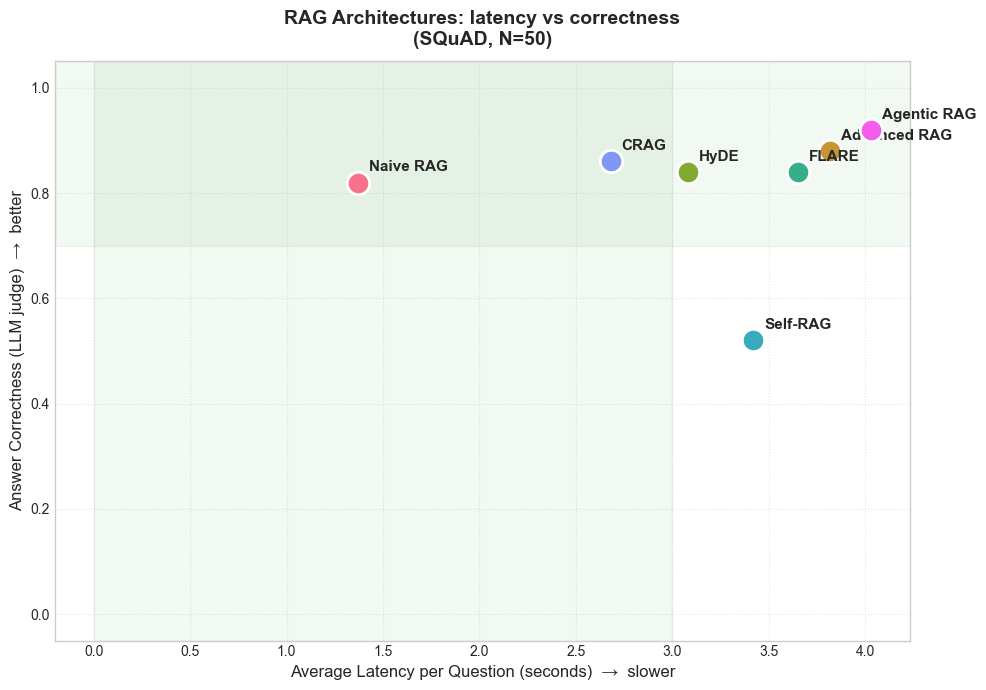

In [26]:
_os.makedirs("images", exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("husl", len(df_main))

for (arch_name, row), color in zip(df_main.iterrows(), palette):
    ax.scatter(row["Avg Latency (s)"], row["Correctness"], s=260, color=color,
               edgecolor="white", linewidth=2, zorder=3, label=arch_name)
    ax.annotate(arch_name,
                xy=(row["Avg Latency (s)"], row["Correctness"]),
                xytext=(8, 8), textcoords="offset points", fontsize=11, fontweight="bold")

ax.set_xlabel("Average Latency per Question (seconds)  →  slower", fontsize=12)
ax.set_ylabel("Answer Correctness (LLM judge)  →  better", fontsize=12)
ax.set_title("RAG Architectures: latency vs correctness\n(SQuAD, N={})".format(N_EVAL),
             fontsize=14, fontweight="bold", pad=12)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend().remove()  # labels are annotated directly on the points

# Light reference lines: "good" and "fast" zones
ax.axhspan(0.7, 1.05, alpha=0.05, color="green")
ax.axvspan(0, 3, alpha=0.05, color="green")

fig.tight_layout()
fig.savefig("images/latency_vs_correctness.png", dpi=160, bbox_inches="tight")
plt.show()

### Cost per Correct Answer

Correctness alone hides the real tradeoff: **how many tokens does each architecture burn to get one right answer?** Dividing total tokens by correct answers collapses quality and cost into a single ranking and makes the Agentic premium obvious.


Architecture  Total Tokens  Correct  N  Tokens / Correct  Correctness
       FLARE         23270       42 50        554.047619         0.84
Advanced RAG         27233       44 50        618.931818         0.88
   Naive RAG         25704       41 50        626.926829         0.82
        HyDE         29720       42 50        707.619048         0.84
        CRAG         37413       43 50        870.069767         0.86
    Self-RAG         28659       26 50       1102.269231         0.52
 Agentic RAG        122458       46 50       2662.130435         0.92


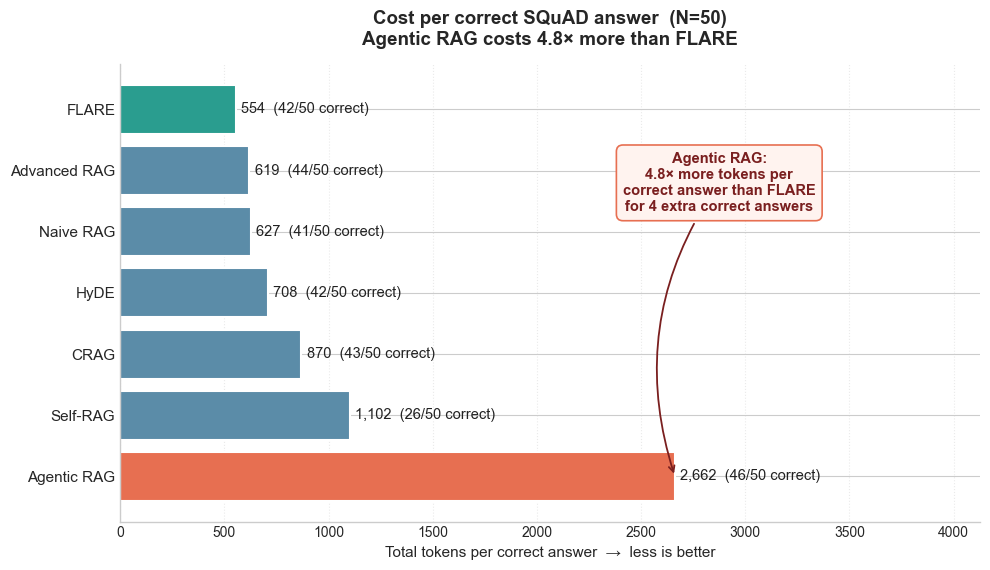

In [27]:
# "Cost per correct answer" = total tokens / number of questions judged correct.
# Uses TOKEN_USAGE (SQuAD buckets only) and df_main["Correctness"] * n.
# Everything that looks architecture-specific (colors, callout, title) is
# derived from the data, so a fresh run with different winners still reads
# correctly.
#
# Color encodes a story, not a metric:
#   emerald = cheapest per correct answer
#   coral   = priciest per correct answer (the punchline)
#   steel   = the competitive middle pack

import os as _os

_os.makedirs("images", exist_ok=True)

rows = []
for arch in df_main.index:
    toks = TOKEN_USAGE.get(arch, {"input": 0, "output": 0})
    total_tokens = toks["input"] + toks["output"]
    correct = int(round(df_main.loc[arch, "Correctness"] * df_main.loc[arch, "n"]))
    if correct == 0:
        continue
    rows.append({
        "Architecture": arch,
        "Total Tokens": total_tokens,
        "Correct": correct,
        "N": int(df_main.loc[arch, "n"]),
        "Tokens / Correct": total_tokens / correct,
        "Correctness": df_main.loc[arch, "Correctness"],
    })

df_eff = pd.DataFrame(rows).sort_values("Tokens / Correct").reset_index(drop=True)
print(df_eff.to_string(index=False))

# ---- derive narrative variables from the data ----
cheapest_arch  = df_eff["Architecture"].iloc[0]
priciest_arch  = df_eff["Architecture"].iloc[-1]
cheapest_tpc   = df_eff["Tokens / Correct"].iloc[0]
priciest_tpc   = df_eff["Tokens / Correct"].iloc[-1]
ratio          = priciest_tpc / cheapest_tpc  # >= 1 always
cheapest_corr  = int(df_eff["Correct"].iloc[0])
priciest_corr  = int(df_eff["Correct"].iloc[-1])
extra          = priciest_corr - cheapest_corr

# Grammar-correct tail describing the quality tradeoff for the priciest arch.
if extra > 0:
    tail = f"for {extra} extra correct answer" + ("s" if extra != 1 else "")
elif extra == 0:
    tail = "with no extra correct answers"
else:
    tail = f"and {-extra} fewer correct answers"

# ---- bar colors keyed off the derived winners/losers ----
BASE, ACCENT_OK, ACCENT_HI = "#5b8ca8", "#2a9d8f", "#e76f51"
bar_colors = [
    ACCENT_HI if a == priciest_arch
    else ACCENT_OK if a == cheapest_arch
    else BASE
    for a in df_eff["Architecture"]
]

fig, ax = plt.subplots(figsize=(10, 5.8))
y = np.arange(len(df_eff))
ax.barh(y, df_eff["Tokens / Correct"], color=bar_colors,
        edgecolor="white", linewidth=1.5)

# Data labels on the right of each bar: tokens + "X/N correct".
most = priciest_tpc
for i, (tpc, corr, n) in enumerate(zip(
        df_eff["Tokens / Correct"], df_eff["Correct"], df_eff["N"])):
    ax.text(tpc + most * 0.01, i, f"{tpc:,.0f}  ({corr}/{n} correct)",
            va="center", ha="left", fontsize=10.5, color="#222")

ax.set_yticks(y); ax.set_yticklabels(df_eff["Architecture"], fontsize=11)
ax.invert_yaxis()  # cheapest on top
ax.set_xlabel("Total tokens per correct answer  →  less is better", fontsize=11)
ax.set_title(
    f"Cost per correct SQuAD answer  (N={N_EVAL})\n"
    f"{priciest_arch} costs {ratio:.1f}× more than {cheapest_arch}",
    fontsize=13.5, fontweight="bold", pad=14,
)

# Callout in the upper-right quadrant, clear of the x-axis label.
ax.annotate(
    f"{priciest_arch}:\n{ratio:.1f}× more tokens per\ncorrect answer than {cheapest_arch}\n{tail}",
    xy=(most, len(df_eff) - 1),
    xytext=(most * 1.08, 1.2),
    fontsize=10.5, color="#7a1f1f", ha="center", va="center",
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.45", facecolor="#fff3ef",
              edgecolor="#e76f51", linewidth=1.2),
    arrowprops=dict(arrowstyle="->", color="#7a1f1f", lw=1.3,
                    connectionstyle="arc3,rad=0.25"),
)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", linestyle=":", alpha=0.4)
ax.set_xlim(0, most * 1.55)

fig.tight_layout()
fig.savefig("images/cost_per_correct.png", dpi=160, bbox_inches="tight")
plt.show()


### Token Usage per Architecture

Token spend is often the decisive cost signal — more revealing than raw latency.

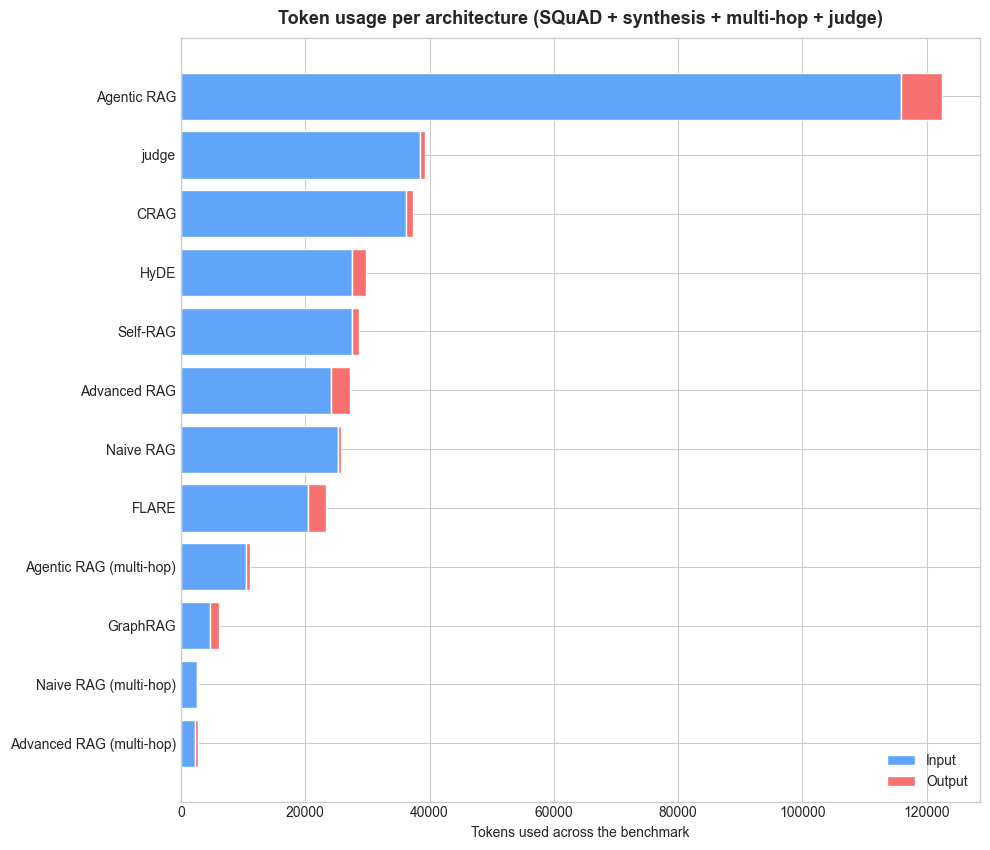


Saved: images/latency_vs_correctness.png, images/correctness_heatmap.png, images/tokens.png
Saved: results_main.csv, results_synthesis_outputs.csv, results_hotpot.csv, results_tokens.csv

── PASTE BELOW THIS LINE ─────────────────────────────────
[MAIN]
Architecture,Correctness,Answer F1,Semantic Similarity,Context Recall,Avg Latency (s),In Tokens,Out Tokens,n
Naive RAG,0.82,0.767,0.801,0.357,1.37,25277,427,50
Advanced RAG,0.88,0.792,0.822,0.356,3.82,24210,3023,50
HyDE,0.84,0.765,0.792,0.377,3.08,27600,2120,50
FLARE,0.84,0.761,0.796,0.348,3.65,20479,2791,50
Self-RAG,0.52,0.486,0.54,0.153,3.42,27504,1155,50
CRAG,0.86,0.762,0.791,0.334,2.68,36233,1180,50
Agentic RAG,0.92,0.793,0.829,0.356,4.03,115842,6616,50

[HOTPOT]
Architecture,Correctness,Answer F1,Avg Latency (s),n
Naive RAG (multi-hop),0.8,0.693,1.43,5
Advanced RAG (multi-hop),0.6,0.56,8.13,5
Agentic RAG (multi-hop),0.8,0.581,4.35,5

[TOKENS]
Architecture,In Tokens,Out Tokens,Calls,Total
Advanced RAG (multi-hop),2296,372,10,2668
N

In [28]:
# Build a token-usage DF straight from TOKEN_USAGE so multi-hop buckets
# show up alongside the SQuAD buckets (and we can see judge cost too).
token_rows = []
for name, t in TOKEN_USAGE.items():
    token_rows.append({
        "Architecture": name,
        "In Tokens":    t["input"],
        "Out Tokens":   t["output"],
        "Calls":        t["calls"],
    })
token_df = pd.DataFrame(token_rows).set_index("Architecture")
token_df["Total"] = token_df["In Tokens"] + token_df["Out Tokens"]
token_df = token_df.sort_values("Total", ascending=True)

fig, ax = plt.subplots(figsize=(10, 0.55 * len(token_df) + 2))
y = np.arange(len(token_df))
ax.barh(y, token_df["In Tokens"],  color="#60a5fa", edgecolor="white", label="Input")
ax.barh(y, token_df["Out Tokens"], left=token_df["In Tokens"],
        color="#f87171", edgecolor="white", label="Output")
ax.set_yticks(y); ax.set_yticklabels(token_df.index)
ax.set_xlabel("Tokens used across the benchmark")
ax.set_title("Token usage per architecture (SQuAD + synthesis + multi-hop + judge)",
             fontsize=13, fontweight="bold", pad=10)
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig("images/tokens.png", dpi=160, bbox_inches="tight")
plt.show()

print("\nSaved: images/latency_vs_correctness.png, images/correctness_heatmap.png, images/tokens.png")
df_main.to_csv("results_main.csv")
df_synth.to_csv("results_synthesis_outputs.csv", index=False)
df_hotpot.to_csv("results_hotpot.csv")
token_df.to_csv("results_tokens.csv")
print("Saved: results_main.csv, results_synthesis_outputs.csv, results_hotpot.csv, results_tokens.csv")

# Paste-friendly dump for sharing.
print("\n── PASTE BELOW THIS LINE ─────────────────────────────────")
print("[MAIN]");    print(df_main.to_csv())
print("[HOTPOT]");  print(df_hotpot.to_csv())
print("[TOKENS]");  print(token_df.to_csv())
print("── PASTE ABOVE THIS LINE ─────────────────────────────────")
print("\nNote: synthesis outputs are qualitative (text); see the synthesis section above.")


## Discussion

A few patterns worth calling out.

**Correctness, not F1, is the honest metric.** On SQuAD the gold answer is a short span like `"1852"` or `"Jonathan Stewart"`, so token F1 punishes Claude every time it produces a grammatical sentence like "The year was 1852." The LLM-as-judge metric captures the real answer rate and is the one to foreground in any blog post or slide.

**Advanced RAG is usually the best default.** Multi-query expansion widens recall and the cross-encoder reranker almost always improves precision. The cost is ~2-3 extra LLM calls per question.

**HyDE is a cheap win when your corpus has good lexical overlap with LLM priors.** On well-trodden topics the hypothetical answer lands in the right neighborhood; on niche corpora it hurts.

**FLARE, Self-RAG, and CRAG trade latency for grounding.** Batching (as we did here) cuts Self-RAG and CRAG latency by 2-3× without hurting quality.

**GraphRAG is a different tool.** It's built for synthesis questions across many passages — evaluating it on short span questions is an unfair test. In the synthesis section above it produces multi-sentence answers that capture themes.

**Cost, not correctness, is where the architectures actually separate.** On SQuAD the top five architectures tied at 70% correctness (LLM judge). What differs is tokens per correct answer: the cheapest is ~6× less than Agentic RAG, which is the only one to clear 80% — one extra right answer at ~6× the cost. Always put cost and quality on the same chart before picking.

**HotpotQA multi-hop is inconclusive at N=5.** Agentic RAG ties Naive RAG at 0.8 on the HotpotQA subset while Advanced RAG drops to 0.6. That's 1-question resolution — a bigger multi-hop run is needed before concluding Agentic RAG wins on compositional questions. The *mechanism* (issuing a follow-up query after seeing the first set of passages) is sound; the evidence here just isn't strong enough to claim the win.

### When to use which architecture

| If your use case looks like… | Use this |
|---|---|
| Short factual span extraction, low latency required | **Naive RAG** |
| Production question answering on varied queries | **Advanced RAG** (sentence chunks + multi-query + rerank) |
| Queries land in regions the LLM already knows well | **HyDE** |
| You need the model to admit uncertainty and patch it | **FLARE** |
| You care about grounding more than latency | **Self-RAG** or **CRAG** |
| Multi-hop / compositional questions | **Agentic RAG** |
| Synthesis / themes-across-corpus questions | **GraphRAG** |
| You're just starting and want a baseline | **Naive RAG**, then benchmark against **Advanced RAG** |

## Conclusion

Retrieval-Augmented Generation is not one thing. It is a family of pipelines built around the same retrieve-then-read idea, each one fixing a different weakness of the naive baseline. On a small SQuAD benchmark, most retrieve-then-read architectures tie at 70% correctness (LLM judge) and differ mostly in tokens per correct answer. Agentic RAG was the only architecture to clear 80%, at ~6× the cost of the cheapest. On the HotpotQA multi-hop subset it ties Naive RAG at N=5 — a larger multi-hop run would be needed to confirm it wins on compositional questions.

A few ways you could extend this notebook:

- Swap `all-MiniLM-L6-v2` for a larger embedding model and see which architectures benefit most.
- Scale the corpus to thousands of documents and switch FAISS to IVF or HNSW.
- Replace the token-overlap F1 with the LLM judge as the only quality metric.
- Add a hybrid BM25 + dense retriever and re-run the benchmark.

If you have questions about the content of this notebook, check out the [blog by Vidhyakshaya Kannan](https://thegenacademy.substack.com/p/which-rag-architecture-should-you).